# RetailInsight: Customer Purchase Analysis

This notebook analyzes customer purchase behavior using the Online Retail Dataset. It covers data cleaning, exploratory data analysis, RFM customer segmentation and a simple high-value customer classifier.

In [1]:
from pathlib import Path
import os
import sys
import warnings

os.environ.setdefault("LOKY_MAX_CPU_COUNT", "4")
os.environ.setdefault("OMP_NUM_THREADS", "1")
warnings.filterwarnings("ignore", message="Could not find the number of physical cores.*")
warnings.filterwarnings("ignore", category=RuntimeWarning, module="threadpoolctl")

import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(PROJECT_ROOT))

from src.analysis import monthly_revenue, order_summary, returning_customer_share, revenue_by_country, top_products
from src.data_processing import load_and_clean
from src.modeling import build_high_value_target, train_high_value_models
from src.segmentation import build_rfm, elbow_scores, fit_kmeans_segments, segment_summary

sns.set_theme(style="whitegrid")
FIGURES_DIR = PROJECT_ROOT / "outputs" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

## 1. Load and Clean Data

In [2]:
transactions = load_and_clean(PROJECT_ROOT / "data" / "Online Retail.xlsx")
transactions.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,InvoiceMonth
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30,2010-12
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010-12
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00,2010-12
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010-12
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010-12


In [3]:
transactions.info()
transactions.describe(include="all")

<class 'pandas.DataFrame'>
RangeIndex: 397884 entries, 0 to 397883
Data columns (total 10 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   InvoiceNo     397884 non-null  str           
 1   StockCode     397884 non-null  object        
 2   Description   397884 non-null  object        
 3   Quantity      397884 non-null  int64         
 4   InvoiceDate   397884 non-null  datetime64[us]
 5   UnitPrice     397884 non-null  float64       
 6   CustomerID    397884 non-null  str           
 7   Country       397884 non-null  str           
 8   TotalPrice    397884 non-null  float64       
 9   InvoiceMonth  397884 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(2), str(4)
memory usage: 30.4+ MB


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,InvoiceMonth
count,397884,397884,397884,397884.000000,397884,397884.000000,397884,397884,397884.000000,397884
unique,18532,3665,3866,NaN,NaN,NaN,4338,37,NaN,13
top,576339,85123A,WHITE HANGING HEART T-LIGHT HOLDER,NaN,NaN,NaN,17841,United Kingdom,NaN,2011-11
freq,542,2035,2028,NaN,NaN,NaN,7847,354321,NaN,64531
mean,NaN,NaN,NaN,12.988238,2011-07-10 23:41:23.511023,3.116488,NaN,NaN,22.397000,NaN
min,NaN,NaN,NaN,1.000000,2010-12-01 08:26:00,0.001000,NaN,NaN,0.001000,NaN
25%,NaN,NaN,NaN,2.000000,2011-04-07 11:12:00,1.250000,NaN,NaN,4.680000,NaN
50%,NaN,NaN,NaN,6.000000,2011-07-31 14:39:00,1.950000,NaN,NaN,11.800000,NaN
75%,NaN,NaN,NaN,12.000000,2011-10-20 14:33:00,3.750000,NaN,NaN,19.800000,NaN
max,NaN,NaN,NaN,80995.000000,2011-12-09 12:50:00,8142.750000,NaN,NaN,168469.600000,NaN


## 2. Exploratory Data Analysis

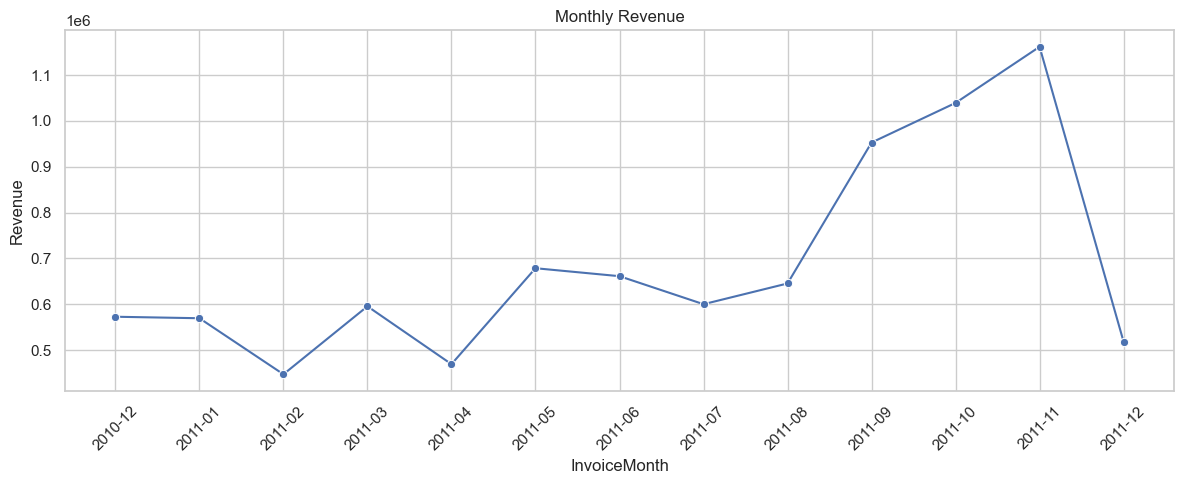

In [4]:
monthly = monthly_revenue(transactions)

plt.figure(figsize=(12, 5))
sns.lineplot(data=monthly, x="InvoiceMonth", y="Revenue", marker="o")
plt.xticks(rotation=45)
plt.title("Monthly Revenue")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "monthly_revenue.png", dpi=150)
plt.show()

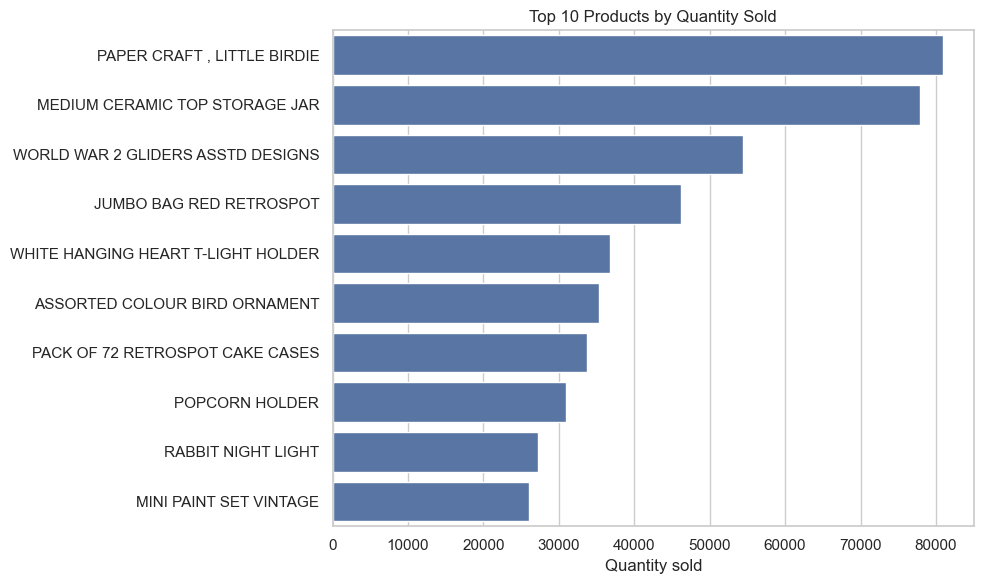

,Description,QuantitySold,Revenue
2310,"PAPER CRAFT , LITTLE BIRDIE",80995,168469.60
1981,MEDIUM CERAMIC TOP STORAGE JAR,77916,81416.73
3775,WORLD WAR 2 GLIDERS ASSTD DESIGNS,54415,13586.25
1751,JUMBO BAG RED RETROSPOT,46181,85220.78
3687,WHITE HANGING HEART T-LIGHT HOLDER,36725,100448.15
206,ASSORTED COLOUR BIRD ORNAMENT,35362,56580.34
2260,PACK OF 72 RETROSPOT CAKE CASES,33693,16394.53
2588,POPCORN HOLDER,30931,23427.71
2644,RABBIT NIGHT LIGHT,27202,51346.20
2036,MINI PAINT SET VINTAGE,26076,16039.24


In [5]:
products = top_products(transactions, n=10)

plt.figure(figsize=(10, 6))
sns.barplot(data=products, y="Description", x="QuantitySold")
plt.title("Top 10 Products by Quantity Sold")
plt.xlabel("Quantity sold")
plt.ylabel("")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "top_products.png", dpi=150)
plt.show()
products

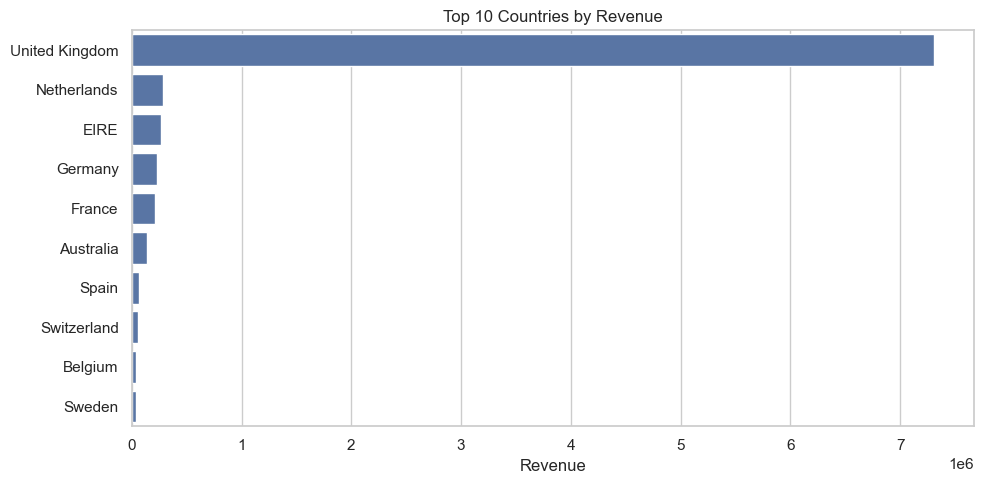

,Country,Revenue
35,United Kingdom,7308391.554
23,Netherlands,285446.340
10,EIRE,265545.900
14,Germany,228867.140
13,France,209024.050
0,Australia,138521.310
30,Spain,61577.110
32,Switzerland,56443.950
3,Belgium,41196.340
31,Sweden,38378.330


In [6]:
countries = revenue_by_country(transactions, n=10)

plt.figure(figsize=(10, 5))
sns.barplot(data=countries, x="Revenue", y="Country")
plt.title("Top 10 Countries by Revenue")
plt.ylabel("")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "revenue_by_country.png", dpi=150)
plt.show()
countries

In [7]:
orders = order_summary(transactions)
average_order_value = orders["OrderValue"].mean()
returning_share = returning_customer_share(transactions)

print(f"Average order value: {average_order_value:.2f}")
print(f"Returning customer share: {returning_share:.1%}")

Average order value: 480.87
Returning customer share: 65.6%


## 3. RFM Segmentation

In [8]:
rfm = build_rfm(transactions)
rfm.head()

,CustomerID,Recency,Frequency,Monetary,AverageOrderValue
0,12346,326,1,77183.60,77183.600000
1,12347,2,7,4310.00,615.714286
2,12348,75,4,1797.24,449.310000
3,12349,19,1,1757.55,1757.550000
4,12350,310,1,334.40,334.400000


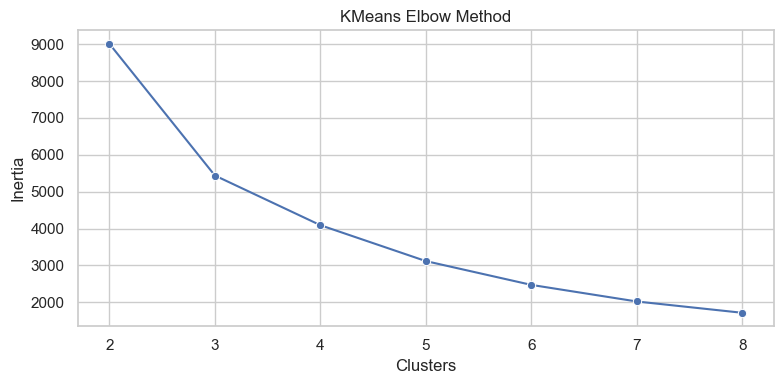

,Clusters,Inertia
0,2,9012.644725
1,3,5439.304686
2,4,4092.144305
3,5,3118.284009
4,6,2472.574514
5,7,2022.412671
6,8,1715.814831


In [9]:
elbow = elbow_scores(rfm, min_clusters=2, max_clusters=8)

plt.figure(figsize=(8, 4))
sns.lineplot(data=elbow, x="Clusters", y="Inertia", marker="o")
plt.title("KMeans Elbow Method")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "kmeans_elbow.png", dpi=150)
plt.show()
elbow

In [10]:
segmented_rfm, kmeans_model, scaler = fit_kmeans_segments(rfm, n_clusters=4)
segment_summary(segmented_rfm)

,Customers,AvgRecency,AvgFrequency,AvgMonetary,AvgOrderValue
Segment,,,,,
High Value,13,7.38,82.54,127338.31,8570.73
Loyal,204,15.50,22.33,12709.09,1080.41
Occasional,3054,43.70,3.68,1359.05,376.76
At Risk,1067,248.08,1.55,480.62,314.81


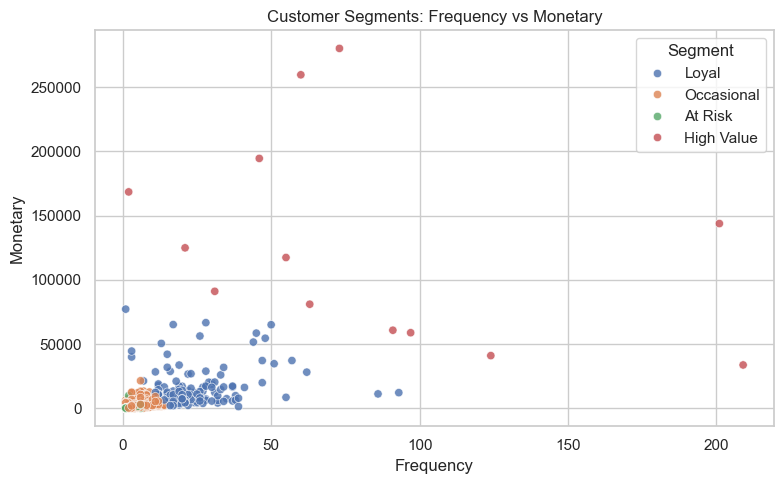

In [11]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=segmented_rfm,
    x="Frequency",
    y="Monetary",
    hue="Segment",
    alpha=0.8,
)
plt.title("Customer Segments: Frequency vs Monetary")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "customer_segments.png", dpi=150)
plt.show()

## 4. High Value Customer Classifier

In [12]:
model_dataset = build_high_value_target(segmented_rfm)
results = train_high_value_models(model_dataset)

for model_name, result in results.items():
    print(model_name)
    print(result["confusion_matrix"])
    print(result["classification_report"])
    print()

logistic_regression
[[1082    0]
 [   0    3]]
{'0': {'precision': 1.0, 'recall': 1.0, 'f1-score': 1.0, 'support': 1082.0}, '1': {'precision': 1.0, 'recall': 1.0, 'f1-score': 1.0, 'support': 3.0}, 'accuracy': 1.0, 'macro avg': {'precision': 1.0, 'recall': 1.0, 'f1-score': 1.0, 'support': 1085.0}, 'weighted avg': {'precision': 1.0, 'recall': 1.0, 'f1-score': 1.0, 'support': 1085.0}}

random_forest
[[1081    1]
 [   1    2]]
{'0': {'precision': 0.9990757855822551, 'recall': 0.9990757855822551, 'f1-score': 0.9990757855822551, 'support': 1082.0}, '1': {'precision': 0.6666666666666666, 'recall': 0.6666666666666666, 'f1-score': 0.6666666666666666, 'support': 3.0}, 'accuracy': 0.9981566820276497, 'macro avg': {'precision': 0.8328712261244609, 'recall': 0.8328712261244609, 'f1-score': 0.8328712261244609, 'support': 1085.0}, 'weighted avg': {'precision': 0.9981566820276497, 'recall': 0.9981566820276497, 'f1-score': 0.9981566820276497, 'support': 1085.0}}



## 5. Business Conclusions

3-5 concise conclusions here